# Анализ обучения: B0 vs M1 (3 seed, independent Oracle)

**Цель:** понять, дала ли M1 реальное обученное смещение распределения относительно B0, и не достигнуто ли улучшение ценой выхода из области применимости.

Используются два архива результатов:
- `B0_NO_PARETO_3SEEDS_RESULTS.zip` — B0 без Pareto и без RL;
- `REINVENT4_MOST_3SEEDS_FINAL_EXPORT.zip` — M1 REINVENT4 Pareto/RL.

### Главные критерии
1. **Primary learning signal:** independent `Oracle JSR(M1) > Oracle JSR(B0)` на всех 3 seed.
2. **Diversity preserved:** относительная потеря Internal Diversity ≤ 5% (аналитический допуск, можно изменить).
3. **Novelty preserved:** Novelty M1 не ниже B0.
4. **Reliability:** сравниваем `Oracle pass ∧ inside AD_A ∧ inside AD_B ∧ SAS≤5`.
5. **AD:** падение доли кандидатов внутри обоих AD считается ухудшением надёжности.

> Важно: по этим export-файлам можно доказать финальное превосходство над baseline, но нельзя восстановить reward curve `step 0 → step N`, потому что training curves не входят в архив.


In [1]:
from pathlib import Path
import zipfile, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import ttest_rel
except Exception:
    ttest_rel = None

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

SEEDS = [42, 101, 2024]
AD_CUTOFF = 0.70
SAS_CUTOFF = 5.0
DIVERSITY_REL_LOSS_TOL = 0.05

print('Seeds:', SEEDS)
print('Diversity tolerance:', f'{DIVERSITY_REL_LOSS_TOL:.0%}')


Seeds: [42, 101, 2024]
Diversity tolerance: 5%


## 1. Загрузка архивов

In [2]:
M1_NAME = 'REINVENT4_MOST_3SEEDS_FINAL_EXPORT.zip'
B0_NAME = 'B0_NO_PARETO_3SEEDS_RESULTS.zip'

def find_file(name):
    for p in [Path('/content')/name, Path('/mnt/data')/name, Path.cwd()/name]:
        if p.exists():
            return p
    return None

m1_zip = find_file(M1_NAME)
b0_zip = find_file(B0_NAME)

if m1_zip is None or b0_zip is None:
    try:
        from google.colab import files
        print('Загрузите оба ZIP-файла результатов...')
        uploaded = files.upload()
        for name in uploaded:
            p = Path('/content')/name
            if name == M1_NAME: m1_zip = p
            if name == B0_NAME: b0_zip = p
    except Exception:
        pass

assert m1_zip is not None and m1_zip.exists(), f'Не найден {M1_NAME}'
assert b0_zip is not None and b0_zip.exists(), f'Не найден {B0_NAME}'

WORK = Path('/content/B0_M1_ANALYSIS') if Path('/content').exists() else Path('/mnt/data/B0_M1_ANALYSIS')
if WORK.exists(): shutil.rmtree(WORK)
(WORK/'M1').mkdir(parents=True)
(WORK/'B0').mkdir(parents=True)
with zipfile.ZipFile(m1_zip) as z: z.extractall(WORK/'M1')
with zipfile.ZipFile(b0_zip) as z: z.extractall(WORK/'B0')
print('M1:', m1_zip)
print('B0:', b0_zip)


M1: /mnt/data/REINVENT4_MOST_3SEEDS_FINAL_EXPORT.zip
B0: /mnt/data/B0_NO_PARETO_3SEEDS_RESULTS.zip


In [3]:
def one(root, name):
    hits = list(Path(root).rglob(name))
    if not hits: raise FileNotFoundError(name)
    return hits[0]

m1_seed = pd.read_csv(one(WORK/'M1', 'M1_seed_metrics.csv'))
m1_mean = pd.read_csv(one(WORK/'M1', 'M1_mean_std.csv'))
m1_gen = pd.read_csv(one(WORK/'M1', 'generated_M1_3seeds.csv'))
m1_profiles = pd.read_csv(one(WORK/'M1', 'M1_profile_summary.csv'))
b0_gen = pd.read_csv(one(WORK/'B0', 'generated_B0.csv'))
b0_summary = pd.read_csv(one(WORK/'B0', 'metrics_summary_B0.csv'))

print('M1 unique rows:', len(m1_gen))
print('B0 rows:', len(b0_gen))


M1 unique rows: 1954
B0 rows: 3000


## 2. Сопоставимые метрики по каждому seed

Ключевая строгая метрика пересчитывается одинаково для B0 и M1:

\[
Reliable\ Oracle\ JSR = \frac{N(Oracle\ pass \land AD_A \land AD_B \land SAS\le 5)}{N_{unique}}
\]


In [4]:
b0_rows=[]
for seed in SEEDS:
    d=b0_gen[b0_gen.seed==seed].copy()
    ad=(d.dist_to_D_A<=AD_CUTOFF)&(d.dist_to_D_B<=AD_CUTOFF)
    sas=d.synthetic_accessibility<=SAS_CUTOFF
    oracle=d.pass_oracle_all.astype(bool)
    surr=d.pass_surrogate_all.astype(bool)
    b0_rows.append(dict(seed=seed, B0_N=len(d), B0_Oracle_JSR=oracle.mean(),
                        B0_Reliable_Oracle_JSR=(oracle&ad&sas).mean(),
                        B0_AD_Both=ad.mean(), B0_SAS_Pass=sas.mean(), B0_Surrogate_JSR=surr.mean()))
b0_key=pd.DataFrame(b0_rows)

m1_rows=[]
for seed in SEEDS:
    d=m1_gen[m1_gen.seed==seed].copy()
    ad=d.inside_both_ad.astype(bool)
    sas=d.sascore_pass.astype(bool)
    oracle=d.oracle_pass_all.astype(bool)
    surr=d.joint_pass.astype(bool)
    m1_rows.append(dict(seed=seed, M1_N=len(d), M1_Oracle_JSR=oracle.mean(),
                        M1_Reliable_Oracle_JSR=(oracle&ad&sas).mean(),
                        M1_AD_Both=ad.mean(), M1_SAS_Pass=sas.mean(), M1_Surrogate_JSR_unique_pool=surr.mean()))
m1_key=pd.DataFrame(m1_rows)

b0_extra=b0_summary[b0_summary.method.eq('B0')].copy()
b0_extra['seed']=b0_extra.seed.astype(int)
b0_extra=b0_extra[['seed','Novelty','Internal_Diversity','Validity','Uniqueness']].rename(columns={
    'Novelty':'B0_Novelty','Internal_Diversity':'B0_Diversity','Validity':'B0_Validity_reported','Uniqueness':'B0_Uniqueness_reported'})

m1_extra=m1_seed[['seed','Novelty','Internal_Diversity','Validity','Uniqueness_across_profiles',
                   'JSR_Surrogate_raw','Evaluator_Oracle_Joint_Agreement','Robust_Surrogate_Rate']].rename(columns={
    'Novelty':'M1_Novelty','Internal_Diversity':'M1_Diversity','Validity':'M1_Validity_final_rows',
    'Uniqueness_across_profiles':'M1_Uniqueness_across_profiles','JSR_Surrogate_raw':'M1_Surrogate_JSR_profile_rows',
    'Evaluator_Oracle_Joint_Agreement':'M1_Evaluator_Oracle_Agreement','Robust_Surrogate_Rate':'M1_Robust_Surrogate_Rate'})

cmp_seed=b0_key.merge(m1_key,on='seed').merge(b0_extra,on='seed').merge(m1_extra,on='seed')
for name,b,m in [
    ('Oracle_JSR','B0_Oracle_JSR','M1_Oracle_JSR'),
    ('Reliable_Oracle_JSR','B0_Reliable_Oracle_JSR','M1_Reliable_Oracle_JSR'),
    ('AD_Both','B0_AD_Both','M1_AD_Both'),
    ('Novelty','B0_Novelty','M1_Novelty'),
    ('Diversity','B0_Diversity','M1_Diversity')]:
    cmp_seed['Delta_'+name]=cmp_seed[m]-cmp_seed[b]

display(cmp_seed.round(6))


,seed,B0_N,B0_Oracle_JSR,B0_Reliable_Oracle_JSR,B0_AD_Both,B0_SAS_Pass,B0_Surrogate_JSR,M1_N,M1_Oracle_JSR,M1_Reliable_Oracle_JSR,M1_AD_Both,M1_SAS_Pass,M1_Surrogate_JSR_unique_pool,B0_Novelty,B0_Diversity,B0_Validity_reported,B0_Uniqueness_reported,M1_Novelty,M1_Diversity,M1_Validity_final_rows,M1_Uniqueness_across_profiles,M1_Surrogate_JSR_profile_rows,M1_Evaluator_Oracle_Agreement,M1_Robust_Surrogate_Rate,Delta_Oracle_JSR,Delta_Reliable_Oracle_JSR,Delta_AD_Both,Delta_Novelty,Delta_Diversity
0,42,1000,0.273,0.220,0.743,0.989,0.219,614,0.438111,0.185668,0.431596,0.983713,0.091205,0.969,0.8766,0.7716,1.0,0.998371,0.873530,1.0,0.175931,0.245928,0.594463,0.000000,0.165111,-0.034332,-0.311404,0.029371,-0.003070
1,101,1000,0.263,0.196,0.726,0.986,0.203,716,0.449721,0.199721,0.435754,0.990223,0.139665,0.979,0.8799,0.7862,1.0,1.000000,0.874270,1.0,0.207116,0.290503,0.622905,0.000000,0.186721,0.003721,-0.290246,0.021000,-0.005630
2,2024,1000,0.299,0.235,0.735,0.985,0.224,624,0.399038,0.206731,0.485577,0.987179,0.113782,0.972,0.8790,0.7616,1.0,0.998397,0.872783,1.0,0.182938,0.256410,0.660256,0.004808,0.100038,-0.028269,-0.249423,0.026397,-0.006217


## 3. Mean ± std и эффект M1 − B0

In [5]:
def mean_std(s):
    a=np.asarray(s,float)
    return a.mean(), a.std(ddof=0)

def pfmt(mu,sd): return f'{mu*100:.2f}% ± {sd*100:.2f}%'
def nfmt(mu,sd): return f'{mu:.4f} ± {sd:.4f}'

rows=[]
for label,bcol,mcol,pct in [
    ('Oracle JSR','B0_Oracle_JSR','M1_Oracle_JSR',True),
    ('Reliable Oracle JSR (Oracle+AD+SAS)','B0_Reliable_Oracle_JSR','M1_Reliable_Oracle_JSR',True),
    ('Inside both AD','B0_AD_Both','M1_AD_Both',True),
    ('SAS pass','B0_SAS_Pass','M1_SAS_Pass',True),
    ('Novelty','B0_Novelty','M1_Novelty',True),
    ('Internal Diversity','B0_Diversity','M1_Diversity',False)]:
    bm,bs=mean_std(cmp_seed[bcol]); mm,ms=mean_std(cmp_seed[mcol])
    delta=mm-bm; rel=delta/bm
    rows.append([label, pfmt(bm,bs) if pct else nfmt(bm,bs), pfmt(mm,ms) if pct else nfmt(mm,ms),
                 f'{delta*100:+.2f} п.п.' if pct else f'{delta:+.4f}', f'{rel*100:+.1f}%'])
summary=pd.DataFrame(rows,columns=['Метрика','B0 mean ± std','M1 mean ± std','Δ M1-B0','Relative change'])
display(summary)


,Метрика,B0 mean ± std,M1 mean ± std,Δ M1-B0,Relative change
0,Oracle JSR,27.83% ± 1.52%,42.90% ± 2.17%,+15.06 п.п.,+54.1%
1,Reliable Oracle JSR (Oracle+AD+SAS),21.70% ± 1.61%,19.74% ± 0.88%,-1.96 п.п.,-9.0%
2,Inside both AD,73.47% ± 0.69%,45.10% ± 2.45%,-28.37 п.п.,-38.6%
3,SAS pass,98.67% ± 0.17%,98.70% ± 0.27%,+0.04 п.п.,+0.0%
4,Novelty,97.33% ± 0.42%,99.89% ± 0.08%,+2.56 п.п.,+2.6%
5,Internal Diversity,0.8785 ± 0.0014,0.8735 ± 0.0006,-0.0050,-0.6%


## 4. Формальный verdict: обучилась или нет

**Не смешиваем два утверждения:**
- «обучилась целевой оптимизации» — определяется ростом independent Oracle JSR;
- «обучилась робастно» — дополнительно требует сохранения AD/reliable success.


In [6]:
b_oracle=cmp_seed.B0_Oracle_JSR.mean(); m_oracle=cmp_seed.M1_Oracle_JSR.mean()
b_rel=cmp_seed.B0_Reliable_Oracle_JSR.mean(); m_rel=cmp_seed.M1_Reliable_Oracle_JSR.mean()
b_ad=cmp_seed.B0_AD_Both.mean(); m_ad=cmp_seed.M1_AD_Both.mean()
b_div=cmp_seed.B0_Diversity.mean(); m_div=cmp_seed.M1_Diversity.mean()
b_nov=cmp_seed.B0_Novelty.mean(); m_nov=cmp_seed.M1_Novelty.mean()

target_all=bool((cmp_seed.Delta_Oracle_JSR>0).all())
div_loss=max(0,(b_div-m_div)/b_div)
flags=[
    ['TARGET_LEARNED: Oracle JSR выше B0 на 3/3 seed', target_all, f'{b_oracle*100:.2f}% → {m_oracle*100:.2f}%'],
    ['DIVERSITY_PRESERVED: потеря <=5%', div_loss<=DIVERSITY_REL_LOSS_TOL, f'{b_div:.4f} → {m_div:.4f}; loss={div_loss*100:.2f}%'],
    ['NOVELTY_PRESERVED', m_nov>=b_nov, f'{b_nov*100:.2f}% → {m_nov*100:.2f}%'],
    ['RELIABILITY_IMPROVED: Oracle+AD+SAS', m_rel>b_rel, f'{b_rel*100:.2f}% → {m_rel*100:.2f}%'],
    ['AD_PRESERVED', m_ad>=b_ad, f'{b_ad*100:.2f}% → {m_ad*100:.2f}%'],
]
verdict=pd.DataFrame(flags,columns=['criterion','pass','evidence'])
display(verdict)

if target_all:
    if all(verdict['pass']):
        final_verdict='ДА: M1 обучилась и улучшение робастно после AD/SAS контроля.'
    else:
        final_verdict='ЧАСТИЧНО: M1 обучилась повышать independent Oracle JSR, но робастная гипотеза не подтверждена из-за AD/reliable success.'
else:
    final_verdict='НЕТ ДОСТАТОЧНОГО EVIDENCE: нет устойчивого выигрыша M1 над B0 по independent Oracle JSR.'
print(final_verdict)


,criterion,pass,evidence
0,TARGET_LEARNED: Oracle JSR выше B0 на 3/3 seed,True,27.83% → 42.90%
1,DIVERSITY_PRESERVED: потеря <=5%,True,0.8785 → 0.8735; loss=0.57%
2,NOVELTY_PRESERVED,True,97.33% → 99.89%
3,RELIABILITY_IMPROVED: Oracle+AD+SAS,False,21.70% → 19.74%
4,AD_PRESERVED,False,73.47% → 45.10%


ЧАСТИЧНО: M1 обучилась повышать independent Oracle JSR, но робастная гипотеза не подтверждена из-за AD/reliable success.


## 5. Точные значения для защиты

In [7]:
oracle_delta=m_oracle-b_oracle
rel_delta=m_rel-b_rel
ad_delta=m_ad-b_ad
nov_delta=m_nov-b_nov
div_delta=m_div-b_div

lines=[
    f'B0 Oracle JSR: {b_oracle*100:.2f}% ± {cmp_seed.B0_Oracle_JSR.std(ddof=0)*100:.2f}%',
    f'M1 Oracle JSR: {m_oracle*100:.2f}% ± {cmp_seed.M1_Oracle_JSR.std(ddof=0)*100:.2f}%',
    f'Абсолютный прирост: {oracle_delta*100:+.2f} п.п.',
    f'Относительный прирост: {oracle_delta/b_oracle*100:+.1f}%',
    f'M1 лучше B0 на {(cmp_seed.Delta_Oracle_JSR>0).sum()}/3 seed',
    '',
    f'B0 Reliable Oracle JSR (Oracle+AD+SAS): {b_rel*100:.2f}%',
    f'M1 Reliable Oracle JSR (Oracle+AD+SAS): {m_rel*100:.2f}%',
    f'Изменение reliable success: {rel_delta*100:+.2f} п.п.',
    '',
    f'B0 inside both AD: {b_ad*100:.2f}%',
    f'M1 inside both AD: {m_ad*100:.2f}%',
    f'Изменение AD coverage: {ad_delta*100:+.2f} п.п.',
    '',
    f'Novelty: {b_nov*100:.2f}% → {m_nov*100:.2f}% ({nov_delta*100:+.2f} п.п.)',
    f'Diversity: {b_div:.4f} → {m_div:.4f} ({div_delta:+.4f}; {div_delta/b_div*100:+.2f}%)'
]
print('\n'.join(lines))
print('\nФормулировка для защиты:')
print(f'RL дал полезное обученное смещение: independent Oracle JSR вырос с {b_oracle*100:.1f}% до {m_oracle*100:.1f}% и M1 лучше B0 на всех трёх seed. Diversity практически не изменилась ({b_div:.3f}→{m_div:.3f}), novelty выросла. Но inside-both-AD упал с {b_ad*100:.1f}% до {m_ad*100:.1f}%, поэтому после Oracle+AD+SAS gate M1 не превосходит B0 ({m_rel*100:.1f}% против {b_rel*100:.1f}%). Значит, целевая оптимизация обучилась, но робастность к domain shift остаётся слабым местом.')


B0 Oracle JSR: 27.83% ± 1.52%
M1 Oracle JSR: 42.90% ± 2.17%
Абсолютный прирост: +15.06 п.п.
Относительный прирост: +54.1%
M1 лучше B0 на 3/3 seed

B0 Reliable Oracle JSR (Oracle+AD+SAS): 21.70%
M1 Reliable Oracle JSR (Oracle+AD+SAS): 19.74%
Изменение reliable success: -1.96 п.п.

B0 inside both AD: 73.47%
M1 inside both AD: 45.10%
Изменение AD coverage: -28.37 п.п.

Novelty: 97.33% → 99.89% (+2.56 п.п.)
Diversity: 0.8785 → 0.8735 (-0.0050; -0.57%)

Формулировка для защиты:
RL дал полезное обученное смещение: independent Oracle JSR вырос с 27.8% до 42.9% и M1 лучше B0 на всех трёх seed. Diversity практически не изменилась (0.878→0.874), novelty выросла. Но inside-both-AD упал с 73.5% до 45.1%, поэтому после Oracle+AD+SAS gate M1 не превосходит B0 (19.7% против 21.7%). Значит, целевая оптимизация обучилась, но робастность к domain shift остаётся слабым местом.


## 6. Oracle JSR по seed

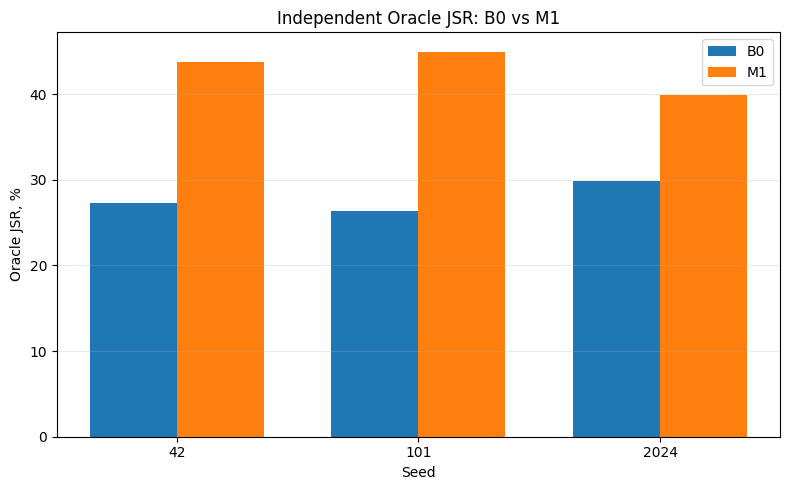

In [8]:
x=np.arange(len(SEEDS)); w=.36
fig,ax=plt.subplots(figsize=(8,5))
ax.bar(x-w/2,cmp_seed.B0_Oracle_JSR*100,w,label='B0')
ax.bar(x+w/2,cmp_seed.M1_Oracle_JSR*100,w,label='M1')
ax.set_xticks(x,[str(s) for s in SEEDS]); ax.set_ylabel('Oracle JSR, %'); ax.set_xlabel('Seed')
ax.set_title('Independent Oracle JSR: B0 vs M1'); ax.legend(); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()


## 7. Δ Oracle JSR M1 − B0

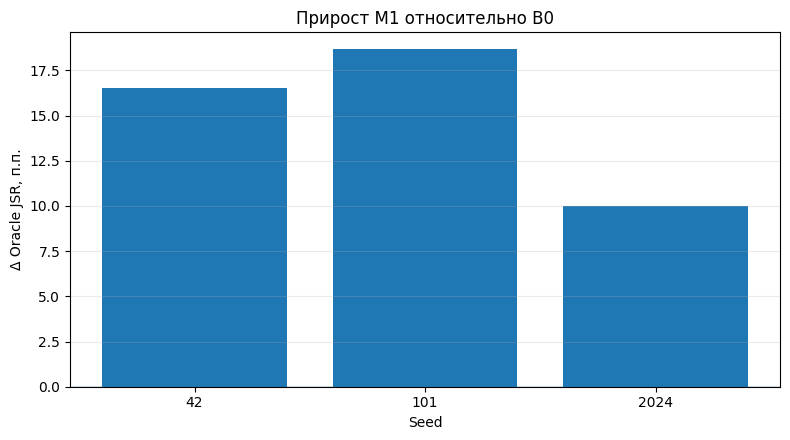

In [9]:
fig,ax=plt.subplots(figsize=(8,4.5))
ax.bar([str(s) for s in SEEDS],cmp_seed.Delta_Oracle_JSR*100)
ax.axhline(0,linewidth=1); ax.set_ylabel('Δ Oracle JSR, п.п.'); ax.set_xlabel('Seed')
ax.set_title('Прирост M1 относительно B0'); ax.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()


## 8. Качество vs надёжность

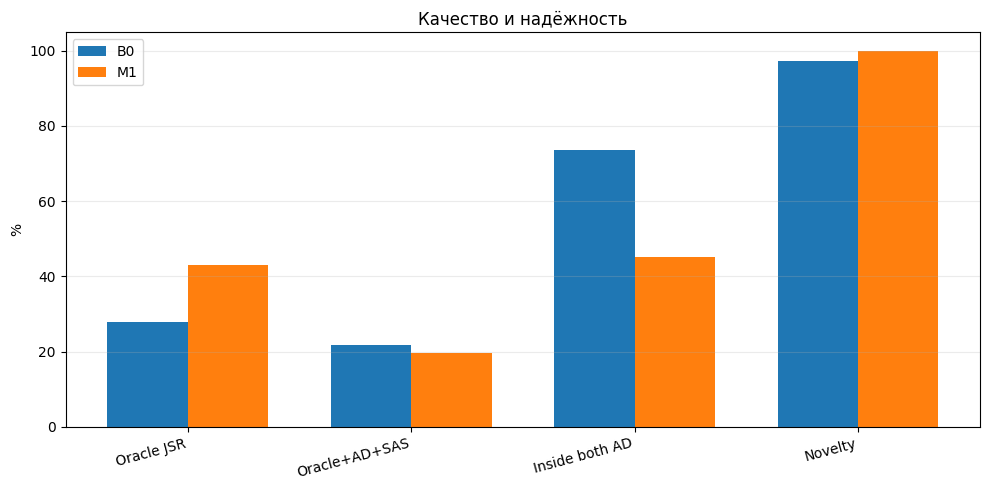

In [10]:
labels=['Oracle JSR','Oracle+AD+SAS','Inside both AD','Novelty']
b=[b_oracle,b_rel,b_ad,b_nov]; m=[m_oracle,m_rel,m_ad,m_nov]
x=np.arange(len(labels)); w=.36
fig,ax=plt.subplots(figsize=(10,5))
ax.bar(x-w/2,np.array(b)*100,w,label='B0'); ax.bar(x+w/2,np.array(m)*100,w,label='M1')
ax.set_xticks(x,labels,rotation=15,ha='right'); ax.set_ylabel('%'); ax.set_title('Качество и надёжность')
ax.legend(); ax.grid(axis='y',alpha=.25); plt.tight_layout(); plt.show()


## 9. Surrogate vs Oracle

`JSR_Surrogate_raw` у M1 считается на profile-level occurrences до дедупликации. `M1_Surrogate_JSR_unique_pool` — на финальном уникальном пуле. Это разные знаменатели, поэтому их нельзя напрямую смешивать.


In [11]:
m1_raw=m1_seed.JSR_Surrogate_raw.mean(); m1_raw_sd=m1_seed.JSR_Surrogate_raw.std(ddof=0)
b0_s=cmp_seed.B0_Surrogate_JSR.mean(); b0_s_sd=cmp_seed.B0_Surrogate_JSR.std(ddof=0)
m1_u=cmp_seed.M1_Surrogate_JSR_unique_pool.mean(); m1_u_sd=cmp_seed.M1_Surrogate_JSR_unique_pool.std(ddof=0)
ag=m1_seed.Evaluator_Oracle_Joint_Agreement.mean(); ag_sd=m1_seed.Evaluator_Oracle_Joint_Agreement.std(ddof=0)
rob=m1_seed.Robust_Surrogate_Rate.mean(); rob_sd=m1_seed.Robust_Surrogate_Rate.std(ddof=0)
secondary=pd.DataFrame([
    ['B0 surrogate JSR (unique baseline)',b0_s,b0_s_sd],
    ['M1 surrogate JSR (profile rows)',m1_raw,m1_raw_sd],
    ['M1 surrogate strict rate (unique pool)',m1_u,m1_u_sd],
    ['M1 evaluator-oracle agreement',ag,ag_sd],
    ['M1 robust surrogate rate',rob,rob_sd]],columns=['metric','mean','std'])
secondary['mean ± std']=secondary.apply(lambda r:f'{r["mean"]*100:.2f}% ± {r["std"]*100:.2f}%',axis=1)
display(secondary[['metric','mean ± std']])
print(f'Evaluator↔Oracle agreement: {ag*100:.1f}%')
print(f'Robust surrogate rate: {rob*100:.2f}%')


,metric,mean ± std
0,B0 surrogate JSR (unique baseline),21.53% ± 0.90%
1,M1 surrogate JSR (profile rows),26.43% ± 1.90%
2,M1 surrogate strict rate (unique pool),11.49% ± 1.98%
3,M1 evaluator-oracle agreement,62.59% ± 2.69%
4,M1 robust surrogate rate,0.16% ± 0.23%


Evaluator↔Oracle agreement: 62.6%
Robust surrogate rate: 0.16%


## 10. Diversity и Novelty по seed

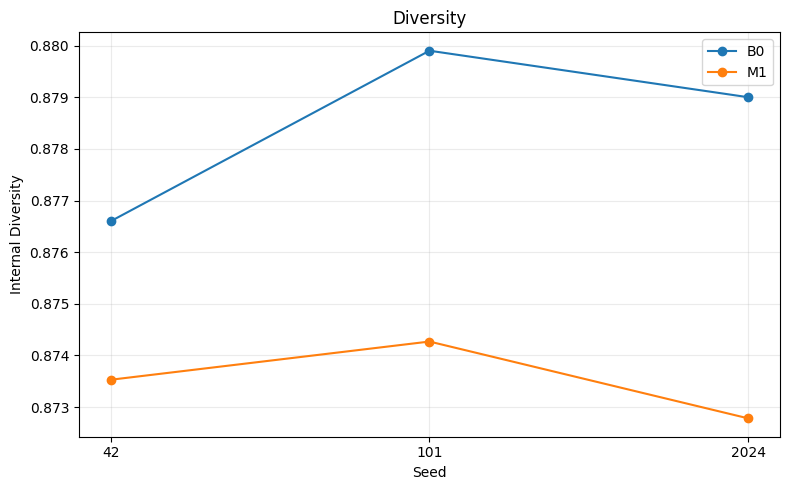

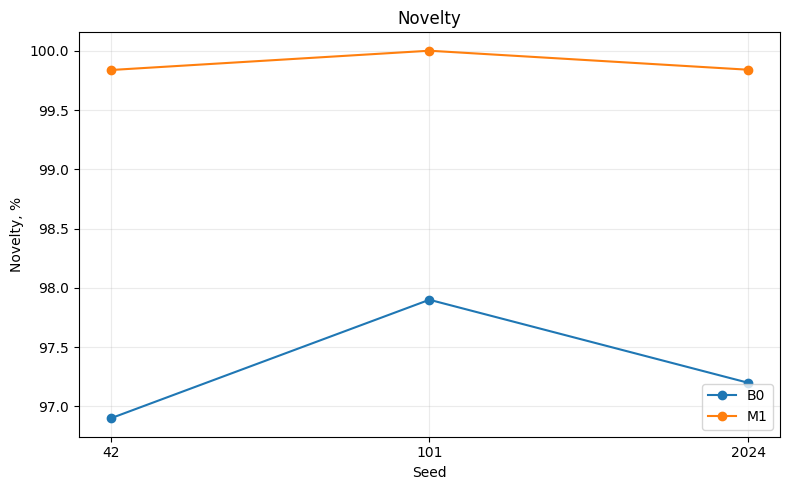

In [12]:
fig,ax=plt.subplots(figsize=(8,5))
ax.plot([str(s) for s in SEEDS],cmp_seed.B0_Diversity,marker='o',label='B0')
ax.plot([str(s) for s in SEEDS],cmp_seed.M1_Diversity,marker='o',label='M1')
ax.set_ylabel('Internal Diversity'); ax.set_xlabel('Seed'); ax.set_title('Diversity'); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(figsize=(8,5))
ax.plot([str(s) for s in SEEDS],cmp_seed.B0_Novelty*100,marker='o',label='B0')
ax.plot([str(s) for s in SEEDS],cmp_seed.M1_Novelty*100,marker='o',label='M1')
ax.set_ylabel('Novelty, %'); ax.set_xlabel('Seed'); ax.set_title('Novelty'); ax.legend(); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()


## 11. Осторожная статистика

`n=3` слишком мало для сильного статистического вывода. p-value здесь только справочный; сильнее аргумент **3/3 seed в одну сторону + большой размер эффекта + independent Oracle**.


In [13]:
if ttest_rel is not None:
    t=ttest_rel(cmp_seed.M1_Oracle_JSR,cmp_seed.B0_Oracle_JSR)
    print(f'Paired t-test: t={t.statistic:.3f}, p={t.pvalue:.4f}')
print('Δ Oracle JSR по seed, п.п.:',(cmp_seed.Delta_Oracle_JSR*100).round(2).tolist())


Paired t-test: t=5.782, p=0.0286
Δ Oracle JSR по seed, п.п.: [16.51, 18.67, 10.0]


## 12. Что нельзя утверждать

- Нельзя утверждать, что reward монотонно рос во время RL: training curve отсутствует в этих архивах.
- Нельзя напрямую сравнивать reported Validity B0 и M1: знаменатели разные.
- Нельзя напрямую сравнивать B0 `Uniqueness=100%` и M1 `cross-profile uniqueness≈19%`: B0 собирал только уникальные структуры, M1 объединяет семь профилей, где хорошие молекулы могут повторяться.
- Рост Oracle JSR показывает улучшение финального распределения относительно baseline, но падение AD показывает риск domain shift.


## 13. Финальный вывод

In [14]:
print(final_verdict)
print(f'Oracle JSR: {b_oracle*100:.2f}% → {m_oracle*100:.2f}% ({(m_oracle-b_oracle)*100:+.2f} п.п.; {(m_oracle/b_oracle-1)*100:+.1f}%)')
print(f'Reliable Oracle JSR: {b_rel*100:.2f}% → {m_rel*100:.2f}% ({(m_rel-b_rel)*100:+.2f} п.п.)')
print(f'Inside both AD: {b_ad*100:.2f}% → {m_ad*100:.2f}% ({(m_ad-b_ad)*100:+.2f} п.п.)')
print(f'Diversity: {b_div:.4f} → {m_div:.4f} ({(m_div/b_div-1)*100:+.2f}%)')
print(f'Novelty: {b_nov*100:.2f}% → {m_nov*100:.2f}%')


ЧАСТИЧНО: M1 обучилась повышать independent Oracle JSR, но робастная гипотеза не подтверждена из-за AD/reliable success.
Oracle JSR: 27.83% → 42.90% (+15.06 п.п.; +54.1%)
Reliable Oracle JSR: 21.70% → 19.74% (-1.96 п.п.)
Inside both AD: 73.47% → 45.10% (-28.37 п.п.)
Diversity: 0.8785 → 0.8735 (-0.57%)
Novelty: 97.33% → 99.89%


## 14. Экспорт таблиц

In [15]:
OUT=WORK/'comparison_outputs'; OUT.mkdir(exist_ok=True)
cmp_seed.to_csv(OUT/'B0_vs_M1_per_seed_recomputed.csv',index=False)
summary.to_csv(OUT/'B0_vs_M1_mean_std_learning_metrics.csv',index=False)
verdict.to_csv(OUT/'learning_verdict.csv',index=False)
secondary.to_csv(OUT/'surrogate_oracle_secondary_metrics.csv',index=False)

conclusion=OUT/'DEFENSE_CONCLUSION.txt'
conclusion.write_text('\n'.join([
    final_verdict,
    f'Oracle JSR: B0 {b_oracle*100:.2f}% -> M1 {m_oracle*100:.2f}% (delta {(m_oracle-b_oracle)*100:+.2f} pp)',
    f'Reliable Oracle JSR: B0 {b_rel*100:.2f}% -> M1 {m_rel*100:.2f}% (delta {(m_rel-b_rel)*100:+.2f} pp)',
    f'AD Both: B0 {b_ad*100:.2f}% -> M1 {m_ad*100:.2f}%',
    f'Diversity: B0 {b_div:.4f} -> M1 {m_div:.4f}',
    f'Novelty: B0 {b_nov*100:.2f}% -> M1 {m_nov*100:.2f}%']),encoding='utf-8')

zip_out=WORK/'B0_vs_M1_ANALYSIS_EXPORT.zip'
with zipfile.ZipFile(zip_out,'w',zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir(): z.write(p,arcname=p.name)
print('Export:',zip_out)


Export: /mnt/data/B0_M1_ANALYSIS/B0_vs_M1_ANALYSIS_EXPORT.zip
